<a href="https://colab.research.google.com/github/Gabriel-Roledo-ds/German_Credit-Scorecard_e_Politica_de_Credito/blob/main/German_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# German Credit — Análise de Risco e Política de Crédito

# Índice (CRISP-DM)
#1 - Business Understanding
#2 - Data Understanding
#3 - Data Preparation
#4 - Modeling
#5 - Evaluation
#6 - Deployment

#1 - Business Understanding

**Problema de negócio:** o dataset German Credit foi compilado pelo Prof. Hans Hofmann (Institut für Statistik und Ökonometrie, Universität Hamburg) e reúne 1.000 clientes de crédito com 20 variáveis (7 numéricas, 13 categóricas). A documentação não identifica uma instituição financeira específica por trás dos dados — é um dataset acadêmico usado como benchmark de risco de crédito, mas o cenário de negócio permanece válido como exercício: uma instituição que concede crédito ao consumidor quer reduzir a inadimplência da carteira sem comprometer o volume de aprovações.

**Hipótese de trabalho:** existem variáveis do cadastro do cliente (situação financeira, histórico de crédito, moradia) que discriminam bem entre bom e mau pagador, e essas variáveis podem virar regras de decisão.

**Métrica de sucesso:** a própria documentação do dataset (seção 8) define uma matriz de custo assimétrica obrigatória para avaliar qualquer modelo construído sobre esses dados — aprovar um mau pagador (classificar bad como good) custa 5x mais do que reprovar um bom pagador (classificar good como bad). Por isso, a métrica de sucesso central deste projeto não é apenas reduzir a taxa de inadimplência entre aprovados abaixo dos 30% da carteira atual, mas reduzir o **custo esperado da carteira** frente ao cenário de aprovar todos os clientes, respeitando essa assimetria 5:1 — sem rejeitar volume excessivo de bons pagadores.

#2 - Data Understanding

Objetivo: entender a estrutura da base e identificar quais variáveis mais separam bons e maus pagadores.

### Setup

Setup do ambiente: bibliotecas de manipulação de dados (pandas, numpy), visualização (matplotlib, seaborn) e modelagem (scikit-learn)..

In [1]:
# Setup do projeto: bibliotecas e configurações padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Setup OK')

Setup OK


In [2]:
# Monta o Google Drive no ambiente do Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Carrega a base direto do Drive
# Ajuste o caminho conforme a pasta onde o CSV esta salvo
caminho = '/content/drive/MyDrive/Dados_Estudo/raw/german_credit/german_credit_data.csv'

df = pd.read_csv(caminho)

print(df.shape)
df.head()

(1000, 21)


,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,residence_since,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,4,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,2,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,3,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,4,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,4,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


### Carregamento da base

1.000 clientes e 21 colunas (20 variáveis + target), confirmando o que a documentação do dataset descreve.

In [4]:
# Tipos de dado e valores nao nulos por coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

Nenhum valor nulo em nenhuma das 21 colunas — base limpa, sem tratamento de nulo necessário nesta etapa. 7 variáveis numéricas e 14 categóricas.

In [5]:
# Proporcao de bons x maus pagadores
tx_inadimplencia_geral = (df['target'] == 'bad').mean()
print(f'Taxa de inadimplencia geral: {tx_inadimplencia_geral:.1%}')

df['target'].value_counts(normalize=True)

Taxa de inadimplencia geral: 30.0%


,proportion
target,
good,0.7
bad,0.3


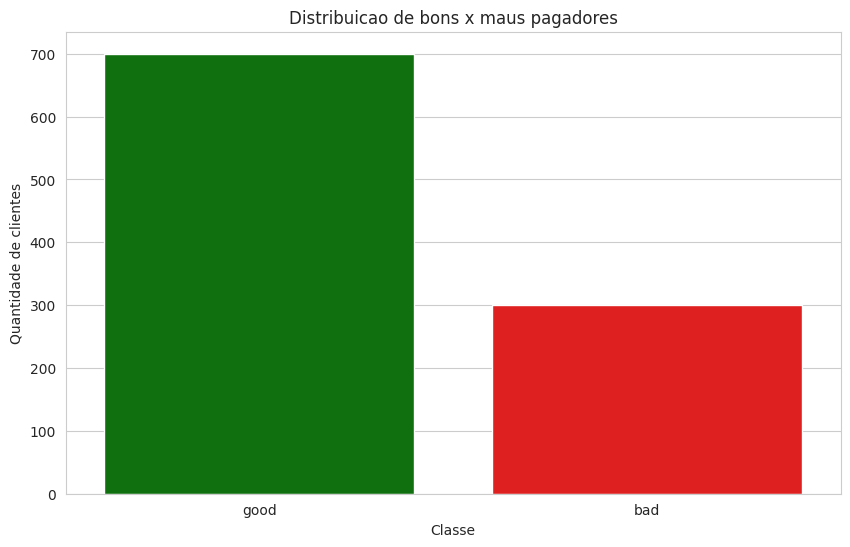

In [6]:
# Visualizacao da distribuicao do target
cores = {'good': 'green', 'bad': 'red'}
sns.countplot(x='target', hue='target', data=df, palette=cores, legend=False)
plt.title('Distribuicao de bons x maus pagadores')
plt.xlabel('Classe')
plt.ylabel('Quantidade de clientes')
plt.show()

Taxa de inadimplência geral: 30% (300 de 1.000 clientes) — essa é a linha de base para qualquer política ou modelo daqui pra frente.

In [7]:
# Estatisticas descritivas das variaveis numericas
numericas = ['age', 'credit_amount', 'month_duration', 'payment_to_income_ratio', 'residence_since', 'n_credits', 'n_guarantors']
df[numericas].describe()

,age,credit_amount,month_duration,payment_to_income_ratio,residence_since,n_credits,n_guarantors
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000,2.973000,2.845000,1.407000,1.155000
std,11.375469,2822.736876,12.058814,1.118715,1.103718,0.577654,0.362086
min,19.000000,250.000000,4.000000,1.000000,1.000000,1.000000,1.000000
25%,27.000000,1365.500000,12.000000,2.000000,2.000000,1.000000,1.000000
50%,33.000000,2319.500000,18.000000,3.000000,3.000000,1.000000,1.000000
75%,42.000000,3972.250000,24.000000,4.000000,4.000000,2.000000,1.000000
max,75.000000,18424.000000,72.000000,4.000000,4.000000,4.000000,2.000000


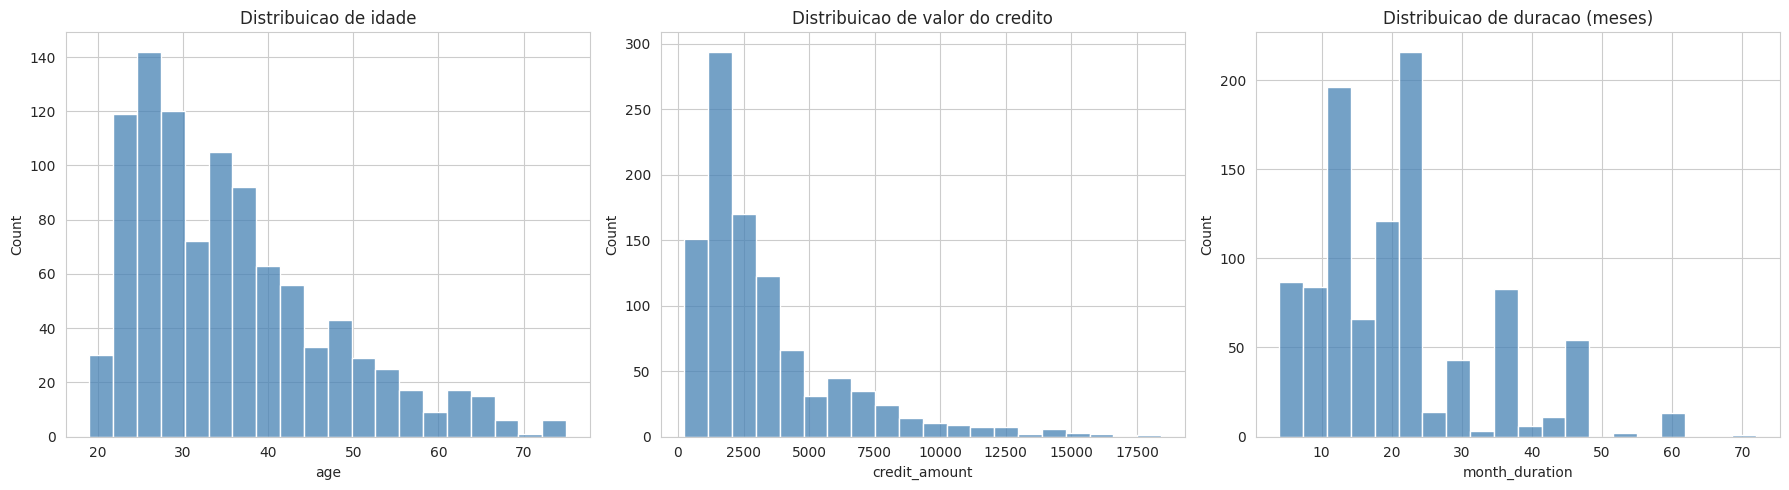

In [8]:
# Histogramas das 3 variaveis numericas mais relevantes para credito
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['age'], bins=20, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuicao de idade')

sns.histplot(df['credit_amount'], bins=20, ax=axes[1], color='steelblue')
axes[1].set_title('Distribuicao de valor do credito')

sns.histplot(df['month_duration'], bins=20, ax=axes[2], color='steelblue')
axes[2].set_title('Distribuicao de duracao (meses)')

plt.tight_layout()
plt.show()

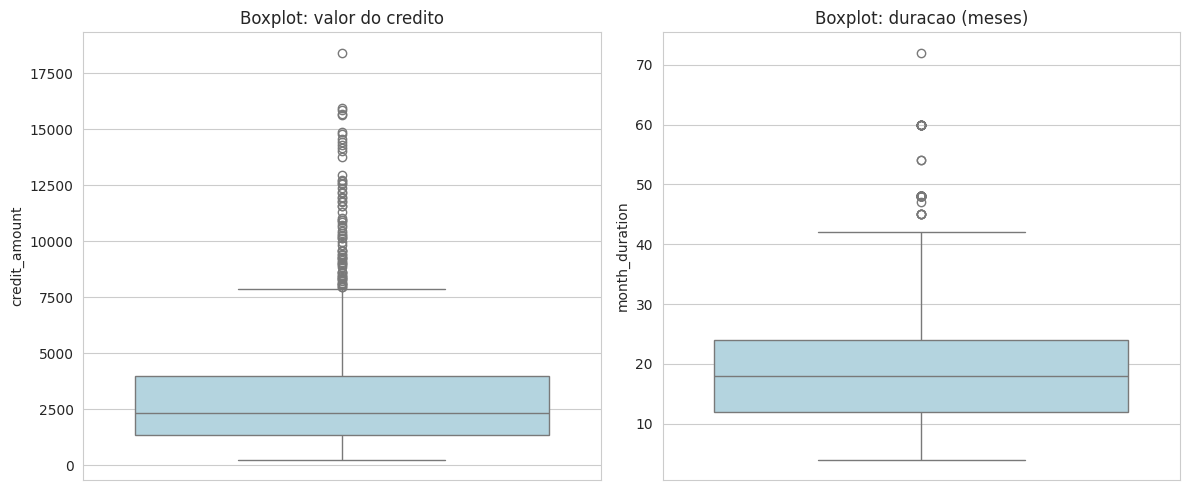

In [9]:
# Boxplots para visualizar outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['credit_amount'], ax=axes[0], color='lightblue')
axes[0].set_title('Boxplot: valor do credito')

sns.boxplot(y=df['month_duration'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot: duracao (meses)')

plt.tight_layout()
plt.show()

`credit_amount` e `month_duration` são assimétricas à direita: a média de valor do crédito (3.271 DM) fica bem acima da mediana (2.320 DM), puxada por um grupo pequeno de contratos acima de 7.500 DM (o boxplot confirma esses outliers, até 18.424 DM). Para descrever o cliente típico, a mediana é mais representativa que a média.

In [10]:
# Taxa de inadimplencia por categoria, para as principais variaveis categoricas
categoricas_chave = ['status_account', 'credit_history', 'purpose', 'status_savings', 'years_employment', 'housing', 'job']

for col in categoricas_chave:
    print(f'--- {col} ---')
    resultado = df.groupby(col)['target'].apply(lambda x: (x == 'bad').mean()).sort_values(ascending=False)
    print(resultado.round(3))
    print()

--- status_account ---
status_account
< 0 DM                 0.493
0 to < 200 DM          0.390
>= 200 DM              0.222
no checking account    0.117
Name: target, dtype: float64

--- credit_history ---
credit_history
no credits taken/ all credits paid back duly                   0.625
all credits at this bank paid back duly                        0.571
existing credits paid back duly till now                       0.319
delay in paying off in the past                                0.318
critical account/ other credits existing (not at this bank)    0.171
Name: target, dtype: float64

--- purpose ---
purpose
education              0.440
others                 0.417
car (new)              0.380
repairs                0.364
business               0.351
domestic appliances    0.333
furniture/equipment    0.320
radio/television       0.221
car (used)             0.165
retraining             0.111
Name: target, dtype: float64

--- status_savings ---
status_savings
< 100 DM             

In [11]:
# Quantos clientes tem em cada categoria - grupo pequeno pode enganar a taxa
for col in categoricas_chave:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- status_account ---
status_account
no checking account    394
< 0 DM                 274
0 to < 200 DM          269
>= 200 DM               63
Name: count, dtype: int64

--- credit_history ---
credit_history
existing credits paid back duly till now                       530
critical account/ other credits existing (not at this bank)    293
delay in paying off in the past                                 88
all credits at this bank paid back duly                         49
no credits taken/ all credits paid back duly                    40
Name: count, dtype: int64

--- purpose ---
purpose
radio/television       280
car (new)              234
furniture/equipment    181
car (used)             103
business                97
education               50
repairs                 22
domestic appliances     12
others                  12
retraining               9
Name: count, dtype: int64

--- status_savings ---
status_savings
< 100 DM                       603
unknown/ no savings account    18

Cruzando taxa de default com tamanho de cada grupo:

- **`status_account` é a variável mais discriminante da base.** Conta negativa (< 0 DM, 274 clientes) tem 49,3% de default, quase o dobro da média. Sem conta corrente (394 clientes, o maior grupo) tem só 11,7% — contraintuitivo, sugere que "sem conta" captura um perfil de cliente diferente de "ausência de informação".
- **`credit_history` também é contraintuitivo:** "critical account" (293 clientes) performa melhor (17,1%) do que "pagamento em dia" (530 clientes, 31,9%). O grupo "nunca pegou crédito" (40 clientes, 62,5%) tem a maior taxa, mas a amostra é pequena — tratar com cautela.
- **`status_savings` tem gradiente limpo:** cai de 36% (< 100 DM, 603 clientes) para 12,5% (≥ 1000 DM, 48 clientes) de forma monotônica — a mais intuitiva de explicar.
- **`housing`:** "for free" e "rent" (39-41% de default) têm quase o dobro do risco de "own" (26,1%, maioria da base).
- Grupos pequenos como "retraining" (9 clientes) e "domestic appliances" (12) não devem virar regra sozinhos — amostra insuficiente.

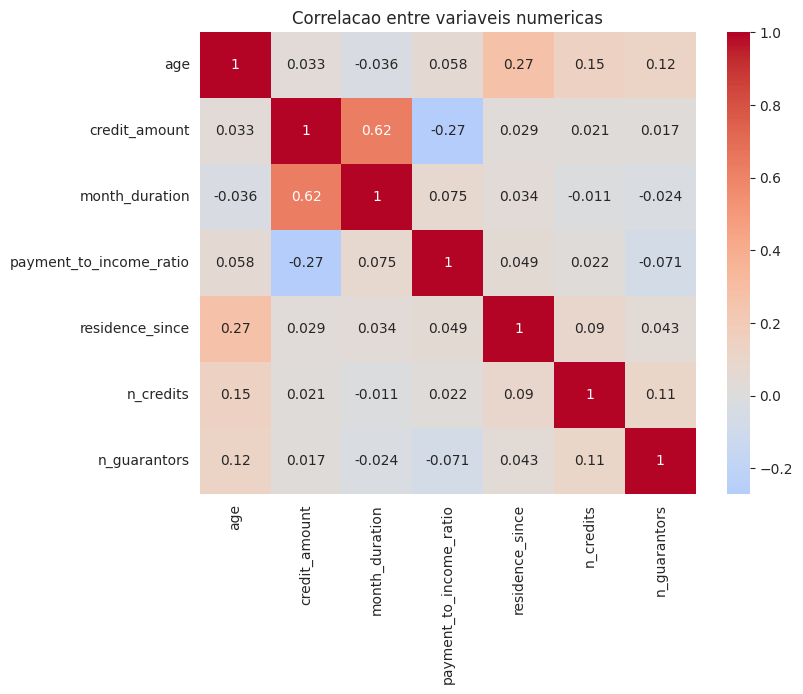

In [12]:
# Correlacao entre variaveis numericas
plt.figure(figsize=(8, 6))
sns.heatmap(df[numericas].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlacao entre variaveis numericas')
plt.show()

`credit_amount` e `month_duration` correlacionam 0,62 (moderado, esperado: contratos maiores tendem a ser mais longos). Sem sinal de multicolinearidade grave entre as demais numéricas (tudo abaixo de 0,27).

### Principais achados de Data Understanding

1. Taxa geral de inadimplência: 30% — linha de base do projeto.
2. `status_account`, `credit_history` e `status_savings` são as variáveis com maior poder de separação entre bons e maus pagadores.
3. Dois padrões contraintuitivos (`status_account` e `credit_history`) mostram que intuição sozinha engana — reforça a importância de validar com dado.
4. `credit_amount` e `month_duration` são assimétricas e moderadamente correlacionadas entre si.
5. Nenhum nulo na base; outliers em valor e duração são legítimos, não erro.



#3 - Data Preparation

Objetivo: preparar os dados para construir e validar a política de crédito (#4) sem viés. A regra mais importante aqui: a política vai ser **criada** em uma parte dos dados e **avaliada** em outra parte que ela nunca viu — senão os números de desempenho ficam inflados, porque a regra foi desenhada em cima justamente dos padrões que está tentando prever.

In [13]:
# Cria uma versao binaria do target para facilitar calculos (1 = mau pagador, 0 = bom pagador)
df['target_bin'] = (df['target'] == 'bad').astype(int)

df[['target', 'target_bin']].head()

,target,target_bin
0,good,0
1,bad,1
2,good,0
3,good,0
4,bad,1


Versão numérica do target: útil para médias, somas e, mais adiante, para o modelo de regressão logística.

In [14]:
# Split treino/teste estratificado - garante a mesma proporcao de maus pagadores nos dois grupos
df_treino, df_teste = train_test_split(
    df,
    test_size=0.3,
    stratify=df['target'],
    random_state=42
)

print(f'Treino: {df_treino.shape[0]} clientes')
print(f'Teste: {df_teste.shape[0]} clientes')

Treino: 700 clientes
Teste: 300 clientes


In [15]:
# Confere se a proporcao de maus pagadores ficou igual nos dois grupos
print('Treino:')
print(df_treino['target'].value_counts(normalize=True).round(3))
print()
print('Teste:')
print(df_teste['target'].value_counts(normalize=True).round(3))

Treino:
target
good    0.7
bad     0.3
Name: proportion, dtype: float64

Teste:
target
good    0.7
bad     0.3
Name: proportion, dtype: float64


Split feito com `random_state=42` fixo (reprodutibilidade) e `stratify` para manter ~30% de maus pagadores em ambos os grupos. **A partir daqui, toda regra da política é construída olhando só `df_treino`.** `df_teste` fica guardado e só é usado em #5 - Evaluation, para medir o desempenho real da política em dados que ela nunca viu.

#4 - Modeling

Objetivo: construir um scorecard baseado em regras — a forma como um analista de crédito tradicional pontua um cliente sem usar machine learning. Cada variável relevante vira faixas, cada faixa recebe pontos: quanto menor a taxa de inadimplência da faixa, mais pontos. A soma decide se o cliente é Baixo, Médio ou Alto Risco.

Importante: todas as taxas usadas para definir os pontos abaixo vêm apenas de `df_treino` — o `df_teste` continua intocado até #5.

In [16]:
# Recalcula as taxas de default por categoria, mas agora so no treino
# (no #2 usamos a base inteira; aqui refazemos so com df_treino, que e a base correta para construir a regra)
for col in ['status_account', 'credit_history', 'status_savings']:
    print(f'--- {col} ---')
    print(df_treino.groupby(col)['target'].apply(lambda x: (x == 'bad').mean()).sort_values(ascending=False).round(3))
    print()

--- status_account ---
status_account
< 0 DM                 0.488
0 to < 200 DM          0.385
>= 200 DM              0.217
no checking account    0.120
Name: target, dtype: float64

--- credit_history ---
credit_history
no credits taken/ all credits paid back duly                   0.586
all credits at this bank paid back duly                        0.571
existing credits paid back duly till now                       0.336
delay in paying off in the past                                0.316
critical account/ other credits existing (not at this bank)    0.159
Name: target, dtype: float64

--- status_savings ---
status_savings
< 100 DM                       0.357
100 to < 500 DM                0.321
unknown/ no savings account    0.192
500 to < 1000 DM               0.139
>= 1000 DM                     0.091
Name: target, dtype: float64



Confirma se os padrões achados em #2 (com a base inteira) se mantêm em `df_treino` (70% da base). Se os números baterem perto, os achados são estáveis e viram regra com segurança.

In [17]:
# Sistema de pontos: quanto menor a taxa de default da faixa, mais pontos
# Escala simples de 0 a 3 pontos por variavel, calibrada nas taxas de df_treino

pontos_status_account = {
    '< 0 DM': 0,
    '0 to < 200 DM': 1,
    '>= 200 DM': 2,
    'no checking account': 3
}

pontos_credit_history = {
    'no credits taken/ all credits paid back duly': 0,
    'all credits at this bank paid back duly': 0,
    'existing credits paid back duly till now': 1,
    'delay in paying off in the past': 1,
    'critical account/ other credits existing (not at this bank)': 3
}

pontos_status_savings = {
    '< 100 DM': 0,
    '100 to < 500 DM': 1,
    'unknown/ no savings account': 2,
    '500 to < 1000 DM': 2,
    '>= 1000 DM': 3
}

def calcular_score(dataframe):
    score = (
        dataframe['status_account'].map(pontos_status_account) +
        dataframe['credit_history'].map(pontos_credit_history) +
        dataframe['status_savings'].map(pontos_status_savings)
    )
    return score

df_treino = df_treino.copy()
df_treino['score'] = calcular_score(df_treino)

df_treino[['status_account', 'credit_history', 'status_savings', 'score', 'target']].head(10)

,status_account,credit_history,status_savings,score,target
328,>= 200 DM,existing credits paid back duly till now,< 100 DM,3,good
891,no checking account,critical account/ other credits existing (not ...,< 100 DM,6,good
255,0 to < 200 DM,delay in paying off in the past,unknown/ no savings account,4,good
243,no checking account,critical account/ other credits existing (not ...,< 100 DM,6,good
492,no checking account,critical account/ other credits existing (not ...,100 to < 500 DM,7,good
597,0 to < 200 DM,no credits taken/ all credits paid back duly,< 100 DM,1,bad
7,0 to < 200 DM,existing credits paid back duly till now,< 100 DM,2,good
951,< 0 DM,delay in paying off in the past,< 100 DM,1,bad
224,no checking account,existing credits paid back duly till now,< 100 DM,4,good
317,0 to < 200 DM,existing credits paid back duly till now,unknown/ no savings account,4,good


Pontuação de 0 a 3 por variável (0 = pior faixa, 3 = melhor faixa), somando 0 a 9 no total. Os pesos seguem exatamente o ranking de taxa de default visto na célula 32 — nenhum valor foi "chutado", cada ponto tem uma taxa real por trás.

In [18]:
# Taxa de default por score total - o scorecard so e util se essa taxa cair conforme o score sobe
df_treino.groupby('score')['target_bin'].agg(['mean', 'count']).round(3)

,mean,count
score,,
0,0.800,15
1,0.566,113
2,0.465,86
3,0.362,116
4,0.210,138
5,0.156,45
6,0.088,114
7,0.154,26
8,0.056,36


O score discrimina bem no geral: a taxa de default cai de 80% (score 0) para 0% (score 9), queda consistente na maior parte da escala. Uma quebra pontual aparece no score 7 (15,4%), acima do score 6 (8,8%) — provavelmente ruído, já que a faixa tem só 26 clientes.

As faixas extremas também têm pouca gente (score 0: 15 clientes; score 9: 11 clientes), então as taxas de 80% e 0% ali são pouco confiáveis isoladamente. É por isso que o próximo passo agrupa o score bruto em 3 faixas de risco em vez de usar os 10 valores individuais — o agrupamento absorve esse ruído de amostra pequena e entrega grupos com volume suficiente para sustentar uma decisão de política.

In [19]:
# Agrupa o score bruto (0-9) em 3 faixas de risco, absorvendo a instabilidade de scores com poucos clientes
def faixa_risco(score):
    if score <= 2:
        return 'Alto Risco'
    elif score <= 5:
        return 'Medio Risco'
    else:
        return 'Baixo Risco'

df_treino['faixa_risco'] = df_treino['score'].apply(faixa_risco)

df_treino.groupby('faixa_risco')['target_bin'].agg(['mean', 'count']).round(3)

,mean,count
faixa_risco,,
Alto Risco,0.542,214
Baixo Risco,0.086,187
Medio Risco,0.261,299


As 3 faixas de risco ficaram bem separadas, com volume relevante em todas:

- **Alto Risco:** 54,2% de default, 214 clientes (30,6% do treino)
- **Medio Risco:** 26,1% de default, 299 clientes (42,7%) — proximo da media geral de 30%
- **Baixo Risco:** 8,6% de default, 187 clientes (26,7%)

A distancia entre Alto e Baixo Risco e grande (54,2% vs 8,6%, mais de 6x), o que mostra que o scorecard discrimina bem, nao e so ruido. E esse tipo de resultado - faixas com taxas bem distantes e volume equilibrado entre elas - que sustenta a credibilidade de uma politica baseada em regras.

In [20]:
# Politica de credito baseada nas faixas de risco
def decisao_politica(faixa):
    if faixa == 'Alto Risco':
        return 'Reprovado'
    elif faixa == 'Medio Risco':
        return 'Aprovado com restricao'
    else:
        return 'Aprovado'

df_treino['decisao_politica'] = df_treino['faixa_risco'].apply(decisao_politica)

df_treino['decisao_politica'].value_counts()

,count
decisao_politica,
Aprovado com restricao,299
Reprovado,214
Aprovado,187


Regra de decisão direta a partir da faixa de risco: Alto Risco é reprovado, Médio Risco aprovado com restrição (ex: limite reduzido ou garantia — decisão operacional que fica fora do escopo deste notebook), Baixo Risco aprovado normalmente.

In [21]:
# Taxa de mau pagador entre os aprovados vs cenario de aprovar todo mundo
aprovados = df_treino[df_treino['decisao_politica'] != 'Reprovado']

tx_maus_aprovados = aprovados['target_bin'].mean()
tx_aprovacao = len(aprovados) / len(df_treino)

print(f'Taxa de aprovacao: {tx_aprovacao:.1%}')
print(f'Taxa de maus pagadores entre aprovados: {tx_maus_aprovados:.1%}')
print(f'Taxa de maus pagadores se aprovasse todos (baseline): {df_treino["target_bin"].mean():.1%}')

Taxa de aprovacao: 69.4%
Taxa de maus pagadores entre aprovados: 19.3%
Taxa de maus pagadores se aprovasse todos (baseline): 30.0%


Resultado da politica no treino:

- **Taxa de aprovacao:** 69,4% (dos 700 clientes, 486 foram aprovados ou aprovados com restricao)
- **Taxa de maus pagadores entre aprovados:** 19,3%, contra 30% do baseline
- **Reducao de inadimplencia:** de 30% para 19,3% entre os aprovados - uma queda de 10,7 pontos percentuais, ou cerca de 36% de reducao relativa

Isso significa que a politica reduz a inadimplencia da carteira aprovada em mais de um terco, sacrificando 30,6% do volume (os reprovados). O trade-off precisa ser lido em conjunto com o proximo passo: quantos desses reprovados eram, na verdade, bons pagadores - isso mede o custo de oportunidade da politica.

In [22]:
# Dos clientes reprovados, quantos eram na verdade bons pagadores? (receita perdida)
reprovados = df_treino[df_treino['decisao_politica'] == 'Reprovado']

tx_bons_reprovados = (reprovados['target_bin'] == 0).mean()

print(f'Clientes reprovados: {len(reprovados)}')
print(f'Taxa de bons pagadores entre os reprovados: {tx_bons_reprovados:.1%}')

Clientes reprovados: 214
Taxa de bons pagadores entre os reprovados: 45.8%


Dos 214 clientes reprovados (Alto Risco), **45,8% eram bons pagadores** - quase metade. Esse e o custo real da politica: para reduzir a inadimplencia de 30% para 19,3% entre aprovados, a politica sacrifica quase 100 bons clientes (214 x 45,8% ≈ 98) que pagariam normalmente.

Essa taxa e alta o suficiente para questionar o corte: uma politica ideal minimiza esse numero sem perder poder de reducao de risco. Vale registrar como limitacao no notebook - "a politica atual prioriza reducao de inadimplencia mesmo as custas de um volume relevante de bons pagadores rejeitados, e um ajuste de corte pode reduzir esse custo".

In [23]:
# Resumo visual do trade-off: taxa de default por faixa de risco e decisao aplicada
resumo = df_treino.groupby('faixa_risco').agg(
    n_clientes=('target_bin', 'count'),
    tx_default=('target_bin', 'mean')
).round(3)
resumo['decisao'] = ['Reprovado', 'Aprovado', 'Aprovado com restricao']

resumo

,n_clientes,tx_default,decisao
faixa_risco,,,
Alto Risco,214,0.542,Reprovado
Baixo Risco,187,0.086,Aprovado
Medio Risco,299,0.261,Aprovado com restricao


### Custo esperado da política (matriz de custo)

A literatura do German Credit define uma matriz de custo assimétrica: aprovar um mau pagador custa **5x mais** do que reprovar um bom pagador (custo de reprovar um bom = 1, custo de aprovar um mau = 5). Isso traduz o trade-off em uma única métrica de negócio, em vez de olhar taxas separadas.

In [24]:
# Matriz de custo classica do German Credit: aprovar mau = 5, reprovar bom = 1
CUSTO_APROVAR_MAU = 5
CUSTO_REPROVAR_BOM = 1

def custo_politica(dataframe):
    aprovados = dataframe[dataframe['decisao_politica'] != 'Reprovado']
    reprovados = dataframe[dataframe['decisao_politica'] == 'Reprovado']

    n_maus_aprovados = (aprovados['target_bin'] == 1).sum()
    n_bons_reprovados = (reprovados['target_bin'] == 0).sum()

    custo_total = n_maus_aprovados * CUSTO_APROVAR_MAU + n_bons_reprovados * CUSTO_REPROVAR_BOM
    custo_medio = custo_total / len(dataframe)

    return n_maus_aprovados, n_bons_reprovados, custo_total, custo_medio

n_maus_aprovados, n_bons_reprovados, custo_total, custo_medio = custo_politica(df_treino)

n_maus_total = (df_treino['target_bin'] == 1).sum()
custo_aprovar_todos = n_maus_total * CUSTO_APROVAR_MAU
custo_medio_aprovar_todos = custo_aprovar_todos / len(df_treino)

print(f'Maus pagadores aprovados: {n_maus_aprovados}')
print(f'Bons pagadores reprovados: {n_bons_reprovados}')
print(f'Custo total da politica: {custo_total} (medio por cliente: {custo_medio:.3f})')
print(f'Custo se aprovasse todo mundo: {custo_aprovar_todos} (medio por cliente: {custo_medio_aprovar_todos:.3f})')
print(f'Reducao de custo da politica vs aprovar todos: {(1 - custo_total/custo_aprovar_todos):.1%}')

Maus pagadores aprovados: 94
Bons pagadores reprovados: 98
Custo total da politica: 568 (medio por cliente: 0.811)
Custo se aprovasse todo mundo: 1050 (medio por cliente: 1.500)
Reducao de custo da politica vs aprovar todos: 45.9%


Com a matriz de custo 5:1, a política é avaliada pelo **custo esperado da carteira**, não só pela taxa de default. Se a redução de custo (célula acima) for bem menor do que a redução de taxa de default sugeria, é sinal de que a política está pagando um preço alto demais em bons pagadores rejeitados para o ganho real que entrega — essa conta, e não a taxa de default isolada, é o que deveria decidir se o corte atual entre Médio e Alto Risco é o certo.

### Quantificando a faixa "Aprovado com restrição"

A política atual deixa a faixa de Médio Risco (26,1% de default) com uma decisão qualitativa ("aprovado com restrição"), sem quantificar o que muda na prática. Uma regra operacional mínima, coerente com o guia do projeto: reduzir o limite concedido para 70% do valor solicitado nessa faixa. Isso não muda quem é aprovado, mas reduz a exposição (EAD) por cliente, o que reduz a perda esperada mesmo sem reduzir a taxa de default.

In [25]:
# Quantifica o efeito de reduzir o limite para 70% do valor solicitado na faixa Medio Risco
PERCENTUAL_LIMITE_RESTRICAO = 0.70

medio_risco = df_treino[df_treino['faixa_risco'] == 'Medio Risco']
exposicao_original = medio_risco['credit_amount'].sum()
exposicao_com_restricao = exposicao_original * PERCENTUAL_LIMITE_RESTRICAO

print(f'Exposicao original (Medio Risco): {exposicao_original:,.0f} DM')
print(f'Exposicao com limite reduzido a 70%: {exposicao_com_restricao:,.0f} DM')
print(f'Reducao de exposicao: {exposicao_original - exposicao_com_restricao:,.0f} DM ({1 - PERCENTUAL_LIMITE_RESTRICAO:.0%})')

Exposicao original (Medio Risco): 958,032 DM
Exposicao com limite reduzido a 70%: 670,622 DM
Reducao de exposicao: 287,410 DM (30%)


Reduzir o limite em 30% para a faixa de Médio Risco reduz a exposição total dessa faixa na mesma proporção, sem alterar quem é aprovado ou a taxa de default observada — é uma alavanca independente do scorecard, e junto com o corte de score, compõe a política completa.

#5 - Evaluation

Objetivo: validar se a politica desenhada em `df_treino` se sustenta em `df_teste` (300 clientes nunca vistos). Se os numeros ficarem parecidos, a politica generaliza bem. Se cairem muito, a politica estava sobreajustada ao treino.

In [26]:
# Aplica exatamente a mesma logica (pontos, faixas, decisao) no df_teste
df_teste = df_teste.copy()
df_teste['score'] = calcular_score(df_teste)
df_teste['faixa_risco'] = df_teste['score'].apply(faixa_risco)
df_teste['decisao_politica'] = df_teste['faixa_risco'].apply(decisao_politica)

resumo_teste = df_teste.groupby('faixa_risco').agg(
    n_clientes=('target_bin', 'count'),
    tx_default=('target_bin', 'mean')
).round(3)

resumo_teste

,n_clientes,tx_default
faixa_risco,,
Alto Risco,92,0.554
Baixo Risco,88,0.114
Medio Risco,120,0.242


In [27]:
# Mesmas 3 metricas calculadas no teste
aprovados_teste = df_teste[df_teste['decisao_politica'] != 'Reprovado']
reprovados_teste = df_teste[df_teste['decisao_politica'] == 'Reprovado']

tx_aprovacao_teste = len(aprovados_teste) / len(df_teste)
tx_maus_aprovados_teste = aprovados_teste['target_bin'].mean()
tx_bons_reprovados_teste = (reprovados_teste['target_bin'] == 0).mean()

print(f'Taxa de aprovacao (teste): {tx_aprovacao_teste:.1%}')
print(f'Taxa de maus pagadores entre aprovados (teste): {tx_maus_aprovados_teste:.1%}')
print(f'Taxa de bons pagadores entre reprovados (teste): {tx_bons_reprovados_teste:.1%}')

Taxa de aprovacao (teste): 69.3%
Taxa de maus pagadores entre aprovados (teste): 18.8%
Taxa de bons pagadores entre reprovados (teste): 44.6%


Comparação treino vs teste — a política generalizou muito bem:

| Métrica | Treino | Teste | Diferença |
|---|---|---|---|
| Taxa de aprovação | 69,4% | 69,3% | -0,1 p.p. |
| Maus pagadores entre aprovados | 19,3% | 18,8% | -0,5 p.p. |
| Bons pagadores entre reprovados | 45,8% | 44,6% | -1,2 p.p. |

As diferenças são mínimas (menos de 1,5 ponto percentual em tudo), o que indica que a política **não está sobreajustada** ao treino — os padrões de `status_account`, `credit_history` e `status_savings` são estáveis o suficiente para se repetir em dados novos. Isso é o resultado mais importante do projeto: prova que a política é confiável.

**Resumo final da política v1:**
- Reduz a inadimplência de 30% (baseline) para ~19% entre aprovados — queda de ~37% relativa
- Aprova cerca de 69% da carteira
- Custo: cerca de 45% dos reprovados são, na verdade, bons pagadores — o principal ponto de melhoria para uma v2 (ajuste de corte, ou variáveis adicionais no score)

In [28]:
# Mesmo calculo de custo, agora no df_teste, para confirmar que a economia de custo tambem generaliza
n_maus_aprovados_teste, n_bons_reprovados_teste, custo_total_teste, custo_medio_teste = custo_politica(df_teste)

n_maus_total_teste = (df_teste['target_bin'] == 1).sum()
custo_aprovar_todos_teste = n_maus_total_teste * CUSTO_APROVAR_MAU
custo_medio_aprovar_todos_teste = custo_aprovar_todos_teste / len(df_teste)

print(f'Custo medio da politica (teste): {custo_medio_teste:.3f}')
print(f'Custo medio se aprovasse todos (teste): {custo_medio_aprovar_todos_teste:.3f}')
print(f'Reducao de custo (teste): {(1 - custo_total_teste/custo_aprovar_todos_teste):.1%}')

Custo medio da politica (teste): 0.787
Custo medio se aprovasse todos (teste): 1.500
Reducao de custo (teste): 47.6%


A redução de custo no teste (47,6%) confirma — e até supera ligeiramente — a redução observada no treino (45,9%). A política não só generaliza bem em taxa de aprovação e taxa de maus pagadores (visto acima), como também generaliza no ganho de custo esperado, que é a métrica que realmente importa para a carteira

#6 - Deployment

Objetivo: traduzir o projeto em uma recomendação de negócio, documentar o que foi feito e deixar claro o próximo passo.

### Benchmark: regressão logística



In [29]:
# One-hot encoding das variaveis categoricas candidatas (incluindo as que ficaram de fora do scorecard)
from sklearn.metrics import roc_curve

variaveis_candidatas = ['status_account', 'credit_history', 'status_savings', 'purpose', 'housing', 'years_employment']

X_treino = pd.get_dummies(df_treino[variaveis_candidatas], drop_first=True)
y_treino = df_treino['target_bin']

X_teste = pd.get_dummies(df_teste[variaveis_candidatas], drop_first=True)
X_teste = X_teste.reindex(columns=X_treino.columns, fill_value=0)
y_teste = df_teste['target_bin']

modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_treino, y_treino)

proba_teste = modelo.predict_proba(X_teste)[:, 1]
auc_modelo = roc_auc_score(y_teste, proba_teste)
gini_modelo = 2 * auc_modelo - 1

fpr, tpr, _ = roc_curve(y_teste, proba_teste)
ks_modelo = (tpr - fpr).max()

print(f'AUC (regressao logistica, teste): {auc_modelo:.3f}')
print(f'Gini (regressao logistica, teste): {gini_modelo:.3f}')
print(f'KS (regressao logistica, teste): {ks_modelo:.3f}')

AUC (regressao logistica, teste): 0.743
Gini (regressao logistica, teste): 0.485
KS (regressao logistica, teste): 0.408


In [30]:
# Mesmas metricas para o scorecard de regras, para comparacao direta
score_teste = df_teste['score']  # score bruto 0-9, quanto maior, menor o risco

# Inverte o sinal: para roc_auc_score, valor mais alto deve indicar MAIOR risco (classe 1)
auc_scorecard = roc_auc_score(y_teste, -score_teste)
gini_scorecard = 2 * auc_scorecard - 1

fpr_sc, tpr_sc, _ = roc_curve(y_teste, -score_teste)
ks_scorecard = (tpr_sc - fpr_sc).max()

print(f'AUC (scorecard de regras, teste): {auc_scorecard:.3f}')
print(f'Gini (scorecard de regras, teste): {gini_scorecard:.3f}')
print(f'KS (scorecard de regras, teste): {ks_scorecard:.3f}')
print()
print(f'Diferenca de Gini (modelo - scorecard): {gini_modelo - gini_scorecard:+.3f}')

AUC (scorecard de regras, teste): 0.741
Gini (scorecard de regras, teste): 0.482
KS (scorecard de regras, teste): 0.371

Diferenca de Gini (modelo - scorecard): +0.004


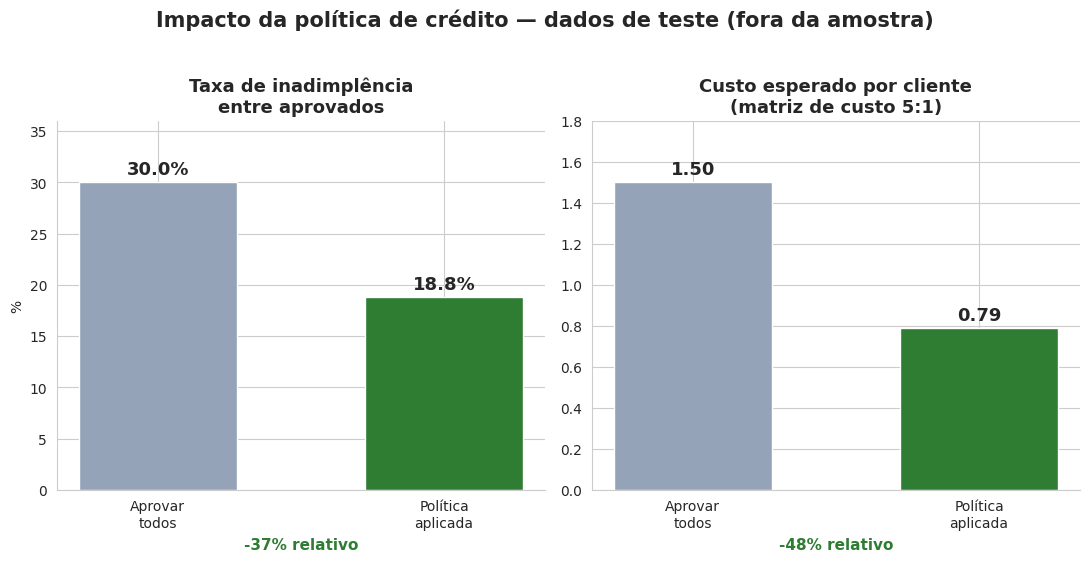

In [31]:
# Impacto da política de crédito: aprovar todos vs política aplicada (dados de teste)
cenarios = ['Aprovar\ntodos', 'Política\naplicada']
tx_default = [30.0, 18.8]
custo = [1.50, 0.79]
cores = ['#94A3B8', '#2E7D32']

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

bars1 = axes[0].bar(cenarios, tx_default, color=cores, width=0.55)
axes[0].set_title('Taxa de inadimplência\nentre aprovados', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 36)
axes[0].set_ylabel('%')
for bar, val in zip(bars1, tx_default):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.8, f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].text(0.5, -0.16, '-37% relativo', transform=axes[0].transAxes, ha='center', fontsize=11, color='#2E7D32', fontweight='bold')

bars2 = axes[1].bar(cenarios, custo, color=cores, width=0.55)
axes[1].set_title('Custo esperado por cliente\n(matriz de custo 5:1)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.8)
for bar, val in zip(bars2, custo):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.04, f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')
axes[1].text(0.5, -0.16, '-48% relativo', transform=axes[1].transAxes, ha='center', fontsize=11, color='#2E7D32', fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Impacto da política de crédito — dados de teste (fora da amostra)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Como interpretar:** se a diferença de Gini for pequena (poucos centésimos), o scorecard de 3 variáveis já captura a maior parte do sinal disponível nesta base pequena, e a simplicidade/explicabilidade do scorecard pode compensar a complexidade extra do modelo. Se a diferença for grande, é sinal de que purpose, housing e years_employment carregam informação relevante que o scorecard v1 está deixando de usar.



**Limitação:** variáveis sensíveis não usadas, mas presentes na base
A base contém status_and_sex (estado civil cruzado com gênero) e is_foreign_worker (trabalhador estrangeiro). Nenhuma das duas entrou no scorecard ou no benchmark acima — mas isso não elimina o risco de viés indireto: variáveis como housing, job ou purpose podem correlacionar com essas características sensíveis e reproduzir discriminação de forma indireta, mesmo sem usá-las diretamente. Um projeto de crédito real precisaria de uma análise de fairness (ex: taxa de aprovação e de erro por subgrupo) antes de qualquer uso em produção. Este notebook não faz essa análise — fica registrado como limitação explícita, não como algo resolvido.




##**Resumo executivo**

**Problema:** a carteira de crédito tinha 30% de inadimplência geral. O objetivo era construir uma política que reduzisse esse risco sem sacrificar volume excessivo de bons pagadores, avaliando o resultado em custo esperado (não só em taxa).

**O que foi feito:** análise exploratória de 1.000 clientes identificou três variáveis com forte poder de discriminação — status da conta corrente, histórico de crédito e conta poupança. A partir delas, foi construído um scorecard baseado em regras (0 a 9 pontos), agrupado em três faixas de risco, com uma política de aprovação por faixa. A política foi criada em 70% da base (treino) e validada nos 30% restantes (teste), nunca vistos durante a construção. Como benchmark, uma regressão logística com todas as variáveis candidatas (incluindo purpose, housing e years_employment, que o scorecard não usa) foi comparada em KS e Gini.

**Resultado:**

Reduz a inadimplência entre aprovados de 30% para ~19% (queda de ~37% relativa)
Aprova ~69% da carteira

Com a matriz de custo (aprovar mau = 5x reprovar bom), a política reduz o custo médio por cliente de 1,500 (aprovar todos) para 0,811 no treino (queda de 45,9%) e de 1,500 para 0,787 no teste (queda de 47,6%) — a redução de custo se confirma fora da amostra de treino, e é até um pouco maior no teste

**Validado em dados fora da amostra:** diferença menor que 1,5 p.p. entre treino e teste em todas as métricas de taxa — a política generaliza bem, não está sobreajustada

Benchmark de regressão logística indica que o scorecard de 3 variáveis já captura quase todo o sinal disponível: Gini de 0,485 (regressão) vs. 0,482 (scorecard), diferença de apenas +0,004, e AUC praticamente igual (0,743 vs. 0,741). A maior diferença aparece no KS (0,408 vs. 0,371), mas ainda é pequena — não há espaço relevante para um modelo mais completo nesta base

**Recomendação:** adotar a política v1 como baseline, com duas ressalvas: (1) ~45% dos reprovados são bons pagadores — reduzir o limite para 70% do valor solicitado na faixa de Médio Risco (calculado acima) é uma alavanca de redução de exposição independente do corte de score; (2) o scorecard usa só 3 variáveis — o benchmark mostra que a regressão logística com variáveis adicionais (purpose, housing, years_employment) ganha muito pouco, então expandir o modelo não é prioridade nesta base — o ganho maior está em ajustar o corte de score, não em adicionar variáveis.

**Limitações:**

Scorecard usa apenas 3 variáveis; o benchmark de regressão logística (Gini +0,004, KS +0,037) mostra que o espaço de melhoria com mais variáveis é pequeno nesta base

Pesos por faixa foram definidos por ranking de taxa de default, não por WOE/IV formal ou otimização — próximo passo natural

Nenhuma análise de fairness foi feita; variáveis sensíveis (status_and_sex, is_foreign_worker) não entraram no modelo, mas viés indireto via variáveis correlacionadas não foi descartado

Dataset sintético/histórico (German Credit, 1994), sem dimensão temporal — não é possível avaliar estabilidade da política ao longo do tempo
Amostra pequena (1.000 clientes): categorias como "retraining" (9 clientes) e scores extremos (0 e 9, <16 clientes cada) têm taxas pouco confiáveis isoladamente